# Spatial bin-size check: extended vs further

Created 2026-06-05 from `/Users/Igniz/Desktop/ICRAR/extended/20251207_check_binsize.ipynb`.

This notebook repeats the original spaxels-per-bin analysis for:

1. the 14 `extended` galaxies, using the old flat `*_SPATIAL_BINNING_maps_extended.fits` and `*_gas_BIN_maps_extended.fits` products;
2. all available `further/v3tk_v7.6.8/<galaxy>/` products;
3. matched extended/further galaxies that exist in both folders;
4. ensemble extended-vs-further comparisons using the 14-galaxy matched sample and all available galaxies.

The two analysis masks match the old notebook logic: finite `BINID` only, then finite `BINID` plus finite `LOGSFR_SURFACE_DENSITY_HII`.

In [1]:
# ------------------------------------------------------------------
# Setup and product discovery
# ------------------------------------------------------------------
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits

EXTENDED_ROOT = Path('/Users/Igniz/Desktop/ICRAR/extended')
FURTHER_ROOT = Path('/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8')

BIN_HDU_CANDIDATES = ('BINID', 'BIN', 'BIN_ID')
HII_SIGSFR_HDU = 'LOGSFR_SURFACE_DENSITY_HII'


@dataclass(frozen=True)
class GalaxyProduct:
    sample: str
    galaxy: str
    bin_path: Path
    gas_path: Path | None = None


def galaxy_from_extended_spatial(path: Path) -> str:
    return path.name.split('_SPATIAL_BINNING_maps_extended.fits')[0]


def discover_extended_products(root: Path = EXTENDED_ROOT) -> dict[str, GalaxyProduct]:
    products = {}
    for bin_path in sorted(root.glob('*_SPATIAL_BINNING_maps_extended.fits')):
        galaxy = galaxy_from_extended_spatial(bin_path)
        gas_path = root / f'{galaxy}_gas_BIN_maps_extended.fits'
        products[galaxy] = GalaxyProduct(
            sample='extended',
            galaxy=galaxy,
            bin_path=bin_path,
            gas_path=gas_path if gas_path.exists() else None,
        )
    return products


def first_existing(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.exists():
            return path
    return None


def discover_further_products(root: Path = FURTHER_ROOT) -> dict[str, GalaxyProduct]:
    products = {}
    for gal_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        galaxy = gal_dir.name
        bin_path = first_existing([
            gal_dir / f'{galaxy}_spatial_binning_maps_further.fits',
            gal_dir / f'{galaxy}_spatial_binning_maps.fits',
        ])
        gas_path = first_existing([
            gal_dir / f'{galaxy}_gas_BIN_maps_further.fits',
            gal_dir / f'{galaxy}_gas_bin_maps_further.fits',
            gal_dir / f'{galaxy}_gas_BIN_maps.fits',
            gal_dir / f'{galaxy}_gas_bin_maps.fits',
        ])
        if bin_path is None:
            continue
        products[galaxy] = GalaxyProduct(
            sample='further',
            galaxy=galaxy,
            bin_path=bin_path,
            gas_path=gas_path,
        )
    return products


extended_products = discover_extended_products()
further_products = discover_further_products()
common_galaxies = sorted(set(extended_products) & set(further_products))
extended_common_products = {g: extended_products[g] for g in common_galaxies}
further_common_products = {g: further_products[g] for g in common_galaxies}

print(f'Extended products: {len(extended_products)} galaxies')
print(sorted(extended_products))
print(f'Further products: {len(further_products)} galaxies with spatial bin maps')
print(sorted(further_products))
print(f'Common products: {len(common_galaxies)} galaxies')
print(common_galaxies)

missing_gas = [p.galaxy for p in further_products.values() if p.gas_path is None]
if missing_gas:
    print(f'Further galaxies without gas-bin product for HII mask: {missing_gas}')

Extended products: 14 galaxies
['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4383', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']
Further products: 27 galaxies with spatial bin maps
['IC3392', 'NGC4064', 'NGC4189', 'NGC4192', 'NGC4293', 'NGC4294', 'NGC4298', 'NGC4302', 'NGC4330', 'NGC4351', 'NGC4383', 'NGC4388', 'NGC4394', 'NGC4396', 'NGC4402', 'NGC4405', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4567_8', 'NGC4569', 'NGC4580', 'NGC4606', 'NGC4607', 'NGC4694', 'NGC4698']
Common products: 14 galaxies
['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4383', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']


In [2]:
# ------------------------------------------------------------------
# Analysis helpers
# ------------------------------------------------------------------
def read_first_hdu(path: Path, names: tuple[str, ...]) -> np.ndarray:
    with fits.open(path, memmap=False) as hdul:
        for name in names:
            if name in hdul:
                return np.asarray(hdul[name].data)
        available = [hdu.name for hdu in hdul]
    shown = available[:12]
    suffix = '...' if len(available) > len(shown) else ''
    raise KeyError(f'None of {names} found in {path}; first HDUs: {shown}{suffix}; total HDUs={len(available)}')


def align_to_overlap(a: np.ndarray, b: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if a.shape == b.shape:
        return a, b
    ny = min(a.shape[0], b.shape[0])
    nx = min(a.shape[1], b.shape[1])
    return a[:ny, :nx], b[:ny, :nx]


def completeness_threshold(counts: np.ndarray, frac: float) -> int:
    sorted_counts = np.sort(counts)
    idx = int(np.ceil(frac * len(sorted_counts))) - 1
    idx = int(np.clip(idx, 0, len(sorted_counts) - 1))
    return int(sorted_counts[idx])


def summarize_counts(counts: np.ndarray) -> dict[str, object]:
    sorted_desc = np.sort(counts)[::-1]
    top5 = sorted_desc[:5].astype(int)
    return {
        'mean': float(np.mean(counts)),
        'median': float(np.median(counts)),
        'std': float(np.std(counts)),
        'min': int(np.min(counts)),
        'max': int(np.max(counts)),
        'num_bins': int(len(counts)),
        'top5': ','.join(str(v) for v in top5),
        'thr_68': completeness_threshold(counts, 0.68),
        'thr_95': completeness_threshold(counts, 0.95),
        'thr_997': completeness_threshold(counts, 0.997),
    }


def compute_product_counts(product: GalaxyProduct, require_hii: bool = False) -> tuple[np.ndarray | None, str | None]:
    try:
        bin_map = read_first_hdu(product.bin_path, BIN_HDU_CANDIDATES)
        if require_hii:
            if product.gas_path is None:
                return None, f'{product.galaxy}: no gas-bin product found'
            sigsfr_hii = read_first_hdu(product.gas_path, (HII_SIGSFR_HDU,))
            original_shapes = (bin_map.shape, sigsfr_hii.shape)
            bin_map, sigsfr_hii = align_to_overlap(bin_map, sigsfr_hii)
            mask = np.isfinite(bin_map) & np.isfinite(sigsfr_hii)
            warning = None
            if original_shapes[0] != original_shapes[1]:
                warning = f'{product.galaxy}: aligned shape {original_shapes[0]} vs {original_shapes[1]} to {bin_map.shape}'
        else:
            mask = np.isfinite(bin_map)
            warning = None

        valid_bins = bin_map[mask]
        if valid_bins.size == 0:
            return None, f'{product.galaxy}: no valid spaxels for require_hii={require_hii}'
        _, counts = np.unique(valid_bins, return_counts=True)
        return counts.astype(int), warning
    except Exception as exc:
        return None, f'{product.galaxy}: {exc}'


def analyze_products(products: dict[str, GalaxyProduct], label: str, require_hii: bool = False):
    rows = []
    per_galaxy_counts = {}
    warnings = []

    for galaxy, product in sorted(products.items()):
        counts, warning = compute_product_counts(product, require_hii=require_hii)
        if warning:
            warnings.append(warning)
        if counts is None:
            continue
        per_galaxy_counts[galaxy] = counts
        row = {'sample': label, 'galaxy': galaxy, 'mask': 'finite_BINID_and_HII_SigmaSFR' if require_hii else 'finite_BINID'}
        row.update(summarize_counts(counts))
        rows.append(row)

    stats = pd.DataFrame(rows)
    all_counts = np.concatenate(list(per_galaxy_counts.values())) if per_galaxy_counts else np.array([], dtype=int)
    return stats, per_galaxy_counts, all_counts, warnings


def print_stats_table(stats: pd.DataFrame, title: str):
    cols = ['galaxy', 'mean', 'median', 'std', 'min', 'max', 'num_bins', 'top5', 'thr_68', 'thr_95', 'thr_997']
    print('\n--- ' + title + ' ---')
    if stats.empty:
        print('No valid galaxies.')
        return
    display_stats = stats[cols].copy()
    for col in ['mean', 'median', 'std']:
        display_stats[col] = display_stats[col].map(lambda v: f'{v:.2f}')
    print(display_stats.to_string(index=False))



def combined_stats_row(label: str, all_counts: np.ndarray, mask: str) -> pd.Series | None:
    if all_counts.size == 0:
        return None
    row = {'sample': label, 'galaxy': 'Combined', 'mask': mask}
    row.update(summarize_counts(all_counts))
    return pd.Series(row)


def print_with_combined(stats: pd.DataFrame, all_counts: np.ndarray, title: str, label: str, require_hii: bool):
    print_stats_table(stats, title)
    mask = 'finite_BINID_and_HII_SigmaSFR' if require_hii else 'finite_BINID'
    combined = combined_stats_row(label, all_counts, mask)
    if combined is not None:
        print('\nCombined:')
        print(combined[['sample', 'galaxy', 'mean', 'median', 'std', 'min', 'max', 'num_bins', 'top5', 'thr_68', 'thr_95', 'thr_997']].to_string())


def plot_per_galaxy_histograms(per_galaxy_counts: dict[str, np.ndarray], title: str, xlabel: str, n_cols: int = 4):
    galaxies = sorted(per_galaxy_counts)
    if not galaxies:
        print(f'No data to plot for {title}')
        return
    n_panels = len(galaxies) + 1
    n_rows = math.ceil(n_panels / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), squeeze=False)
    axes = axes.ravel()

    for i, galaxy in enumerate(galaxies):
        counts = per_galaxy_counts[galaxy]
        axes[i].hist(counts, bins=20, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{galaxy}\nN_bins={len(counts)}, Med={np.median(counts):.1f}')
        axes[i].set_xlabel(xlabel)
        axes[i].set_xscale('log')
        axes[i].set_ylabel('Count')

    all_counts = np.concatenate([per_galaxy_counts[g] for g in galaxies])
    ax = axes[len(galaxies)]
    ax.hist(all_counts, bins=30, color='orange', edgecolor='black', alpha=0.7)
    ax.set_title(f'Combined\nTotal bins={len(all_counts)}')
    ax.set_xlabel(xlabel)
    ax.set_xscale('log')
    ax.set_ylabel('Count')

    for j in range(len(galaxies) + 1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


def compare_stats(left: pd.DataFrame, right: pd.DataFrame, left_name: str, right_name: str) -> pd.DataFrame:
    metrics = ['mean', 'median', 'std', 'min', 'max', 'num_bins', 'thr_68', 'thr_95', 'thr_997']
    merged = left.merge(right, on='galaxy', suffixes=(f'_{left_name}', f'_{right_name}'))
    for metric in metrics:
        merged[f'delta_{metric}'] = merged[f'{metric}_{right_name}'] - merged[f'{metric}_{left_name}']
        denom = merged[f'{metric}_{left_name}'].replace(0, np.nan)
        merged[f'ratio_{metric}'] = merged[f'{metric}_{right_name}'] / denom
    keep = ['galaxy']
    for metric in ['mean', 'median', 'max', 'num_bins', 'thr_68', 'thr_95', 'thr_997']:
        keep.extend([f'{metric}_{left_name}', f'{metric}_{right_name}', f'delta_{metric}', f'ratio_{metric}'])
    return merged[keep].sort_values('galaxy')


def plot_paired_metric_comparison(comparison: pd.DataFrame, left_name: str, right_name: str, title: str):
    metrics = ['median', 'mean', 'max', 'thr_95', 'num_bins']
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 4.2))
    for ax, metric in zip(axes, metrics):
        x = comparison[f'{metric}_{left_name}']
        y = comparison[f'{metric}_{right_name}']
        ax.scatter(x, y, s=35)
        lo = np.nanmin([x.min(), y.min()])
        hi = np.nanmax([x.max(), y.max()])
        ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--')
        ax.set_xlabel(f'{left_name} {metric}')
        ax.set_ylabel(f'{right_name} {metric}')
        ax.set_title(metric)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_ensemble_overlay(count_groups: dict[str, np.ndarray], title: str, xlabel: str):
    fig, ax = plt.subplots(figsize=(9, 6))
    max_count = max((int(np.nanmax(v)) for v in count_groups.values() if len(v)), default=1)
    bins = np.arange(0.5, max_count + 1.5, 1)
    for label, counts in count_groups.items():
        if len(counts) == 0:
            continue
        ax.hist(counts, bins=bins, histtype='step', linewidth=2, label=f'{label} (N={len(counts)})')
    ax.set_xlabel(xlabel)
    ax.set_xscale('log')
    ax.set_ylabel('Number of bins')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [3]:
# ------------------------------------------------------------------
# Physical scale at 16.5 Mpc, matching the old notebook
# ------------------------------------------------------------------
distance_Mpc = 16.5
angular_scale_arcsec = 0.2
physical_scale_pc = distance_Mpc * 1e6 * angular_scale_arcsec / 206265

print(f'Angular scale: {angular_scale_arcsec} arcsec')
print(f'Distance: {distance_Mpc} Mpc')
print(f'Physical scale: {physical_scale_pc:.2f} pc per spaxel')

Angular scale: 0.2 arcsec
Distance: 16.5 Mpc
Physical scale: 16.00 pc per spaxel


## 1. Original 14 extended galaxies


--- Extended 14: finite BINID only ---
 galaxy  mean median    std  min  max  num_bins                    top5  thr_68  thr_95  thr_997
 IC3392 17.95   9.00  34.89    1  431      4077     431,420,406,373,359      14      58      296
NGC4064 16.74   5.00  33.23    1  383      9411     383,365,338,309,307      10      73      241
NGC4192 14.21   8.00  21.12    1  290     34433     290,288,283,263,256      12      51      153
NGC4293 11.86   7.00  14.95    1  225     21133     225,189,171,168,162      11      40      111
NGC4298 26.60  11.00  56.96    1  742     13160     742,703,663,658,638      19      97      505
NGC4330 53.17  22.00 100.77    3  938      2960     938,889,879,790,769      34     207      719
NGC4383 14.31   2.00  65.53    1 1313      9028 1313,1117,1046,1022,974       4      46      666
NGC4396 67.97  30.00 102.93    1  789      2338     789,759,730,717,656      53     315      622
NGC4419  8.94   4.00  23.64    1  434     17291     434,411,388,385,373       6      29

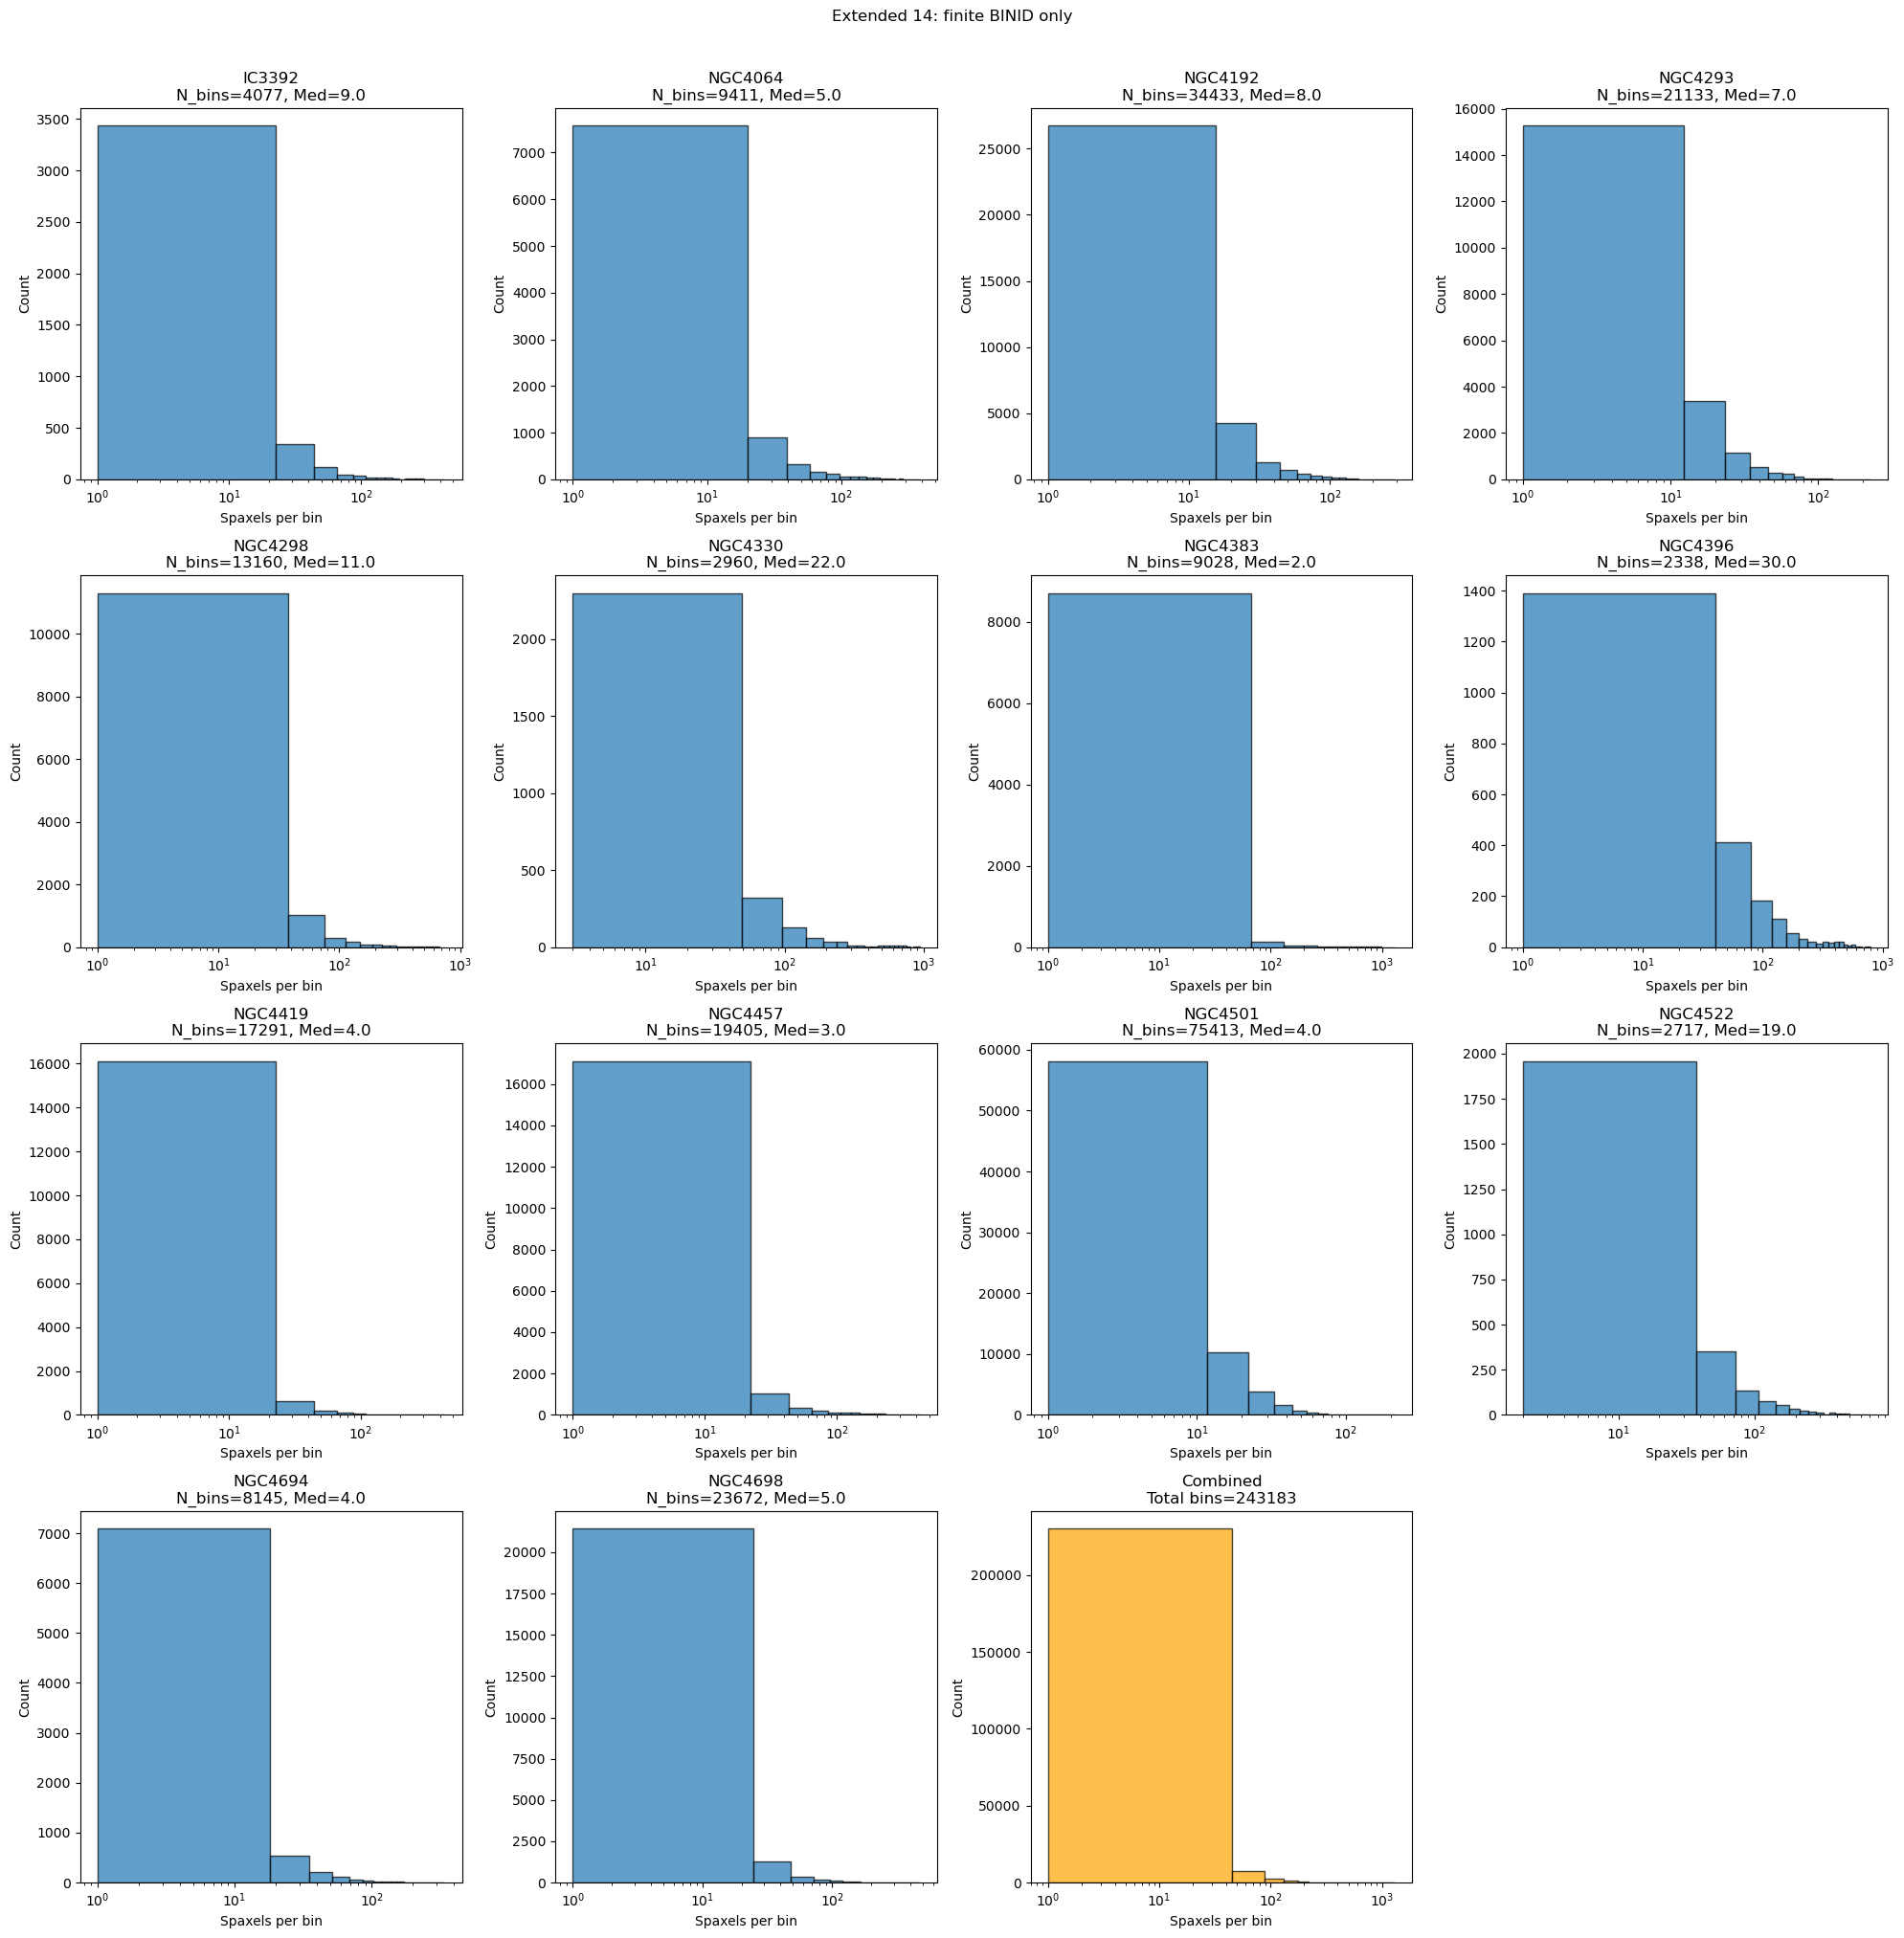

In [4]:
# Finite BINID only: original 14 extended galaxies
ext_stats_binid, ext_counts_binid, ext_all_binid, ext_warnings_binid = analyze_products(
    extended_products, 'extended_14', require_hii=False
)
print_with_combined(ext_stats_binid, ext_all_binid, 'Extended 14: finite BINID only', 'extended_14', False)
if ext_warnings_binid:
    print('\nWarnings:')
    print('\n'.join(ext_warnings_binid))
plot_per_galaxy_histograms(ext_counts_binid, 'Extended 14: finite BINID only', 'Spaxels per bin')


--- Extended 14: finite BINID + finite HII SigmaSFR ---
 galaxy  mean median   std  min  max  num_bins                 top5  thr_68  thr_95  thr_997
 IC3392  6.33   5.00  5.87    1  158      2356     158,123,78,51,23       7      14       21
NGC4064  2.46   2.00  3.31    1   87      2873       87,58,56,53,47       2       5       31
NGC4192 21.09  14.00 22.22    1  244      6925  244,234,201,193,186      21      66      149
NGC4293 12.97   6.00 18.57    1  225       429    225,111,105,97,96      11      45      111
NGC4298 16.43  11.00 18.37    1  254      9529  254,242,231,225,210      17      49      125
NGC4330 24.24  17.00 27.33    3  700      1645  700,255,230,220,201      24      58      201
NGC4383  8.54   2.00 46.16    1 1046      8274 1046,955,914,898,862       3      22      505
NGC4396 46.30  25.00 63.83    1  789      1674  789,730,635,500,462      41     149      442
NGC4419  5.66   4.00 13.19    1  294      1304   294,246,202,171,66       6       9      171
NGC4457  7.51

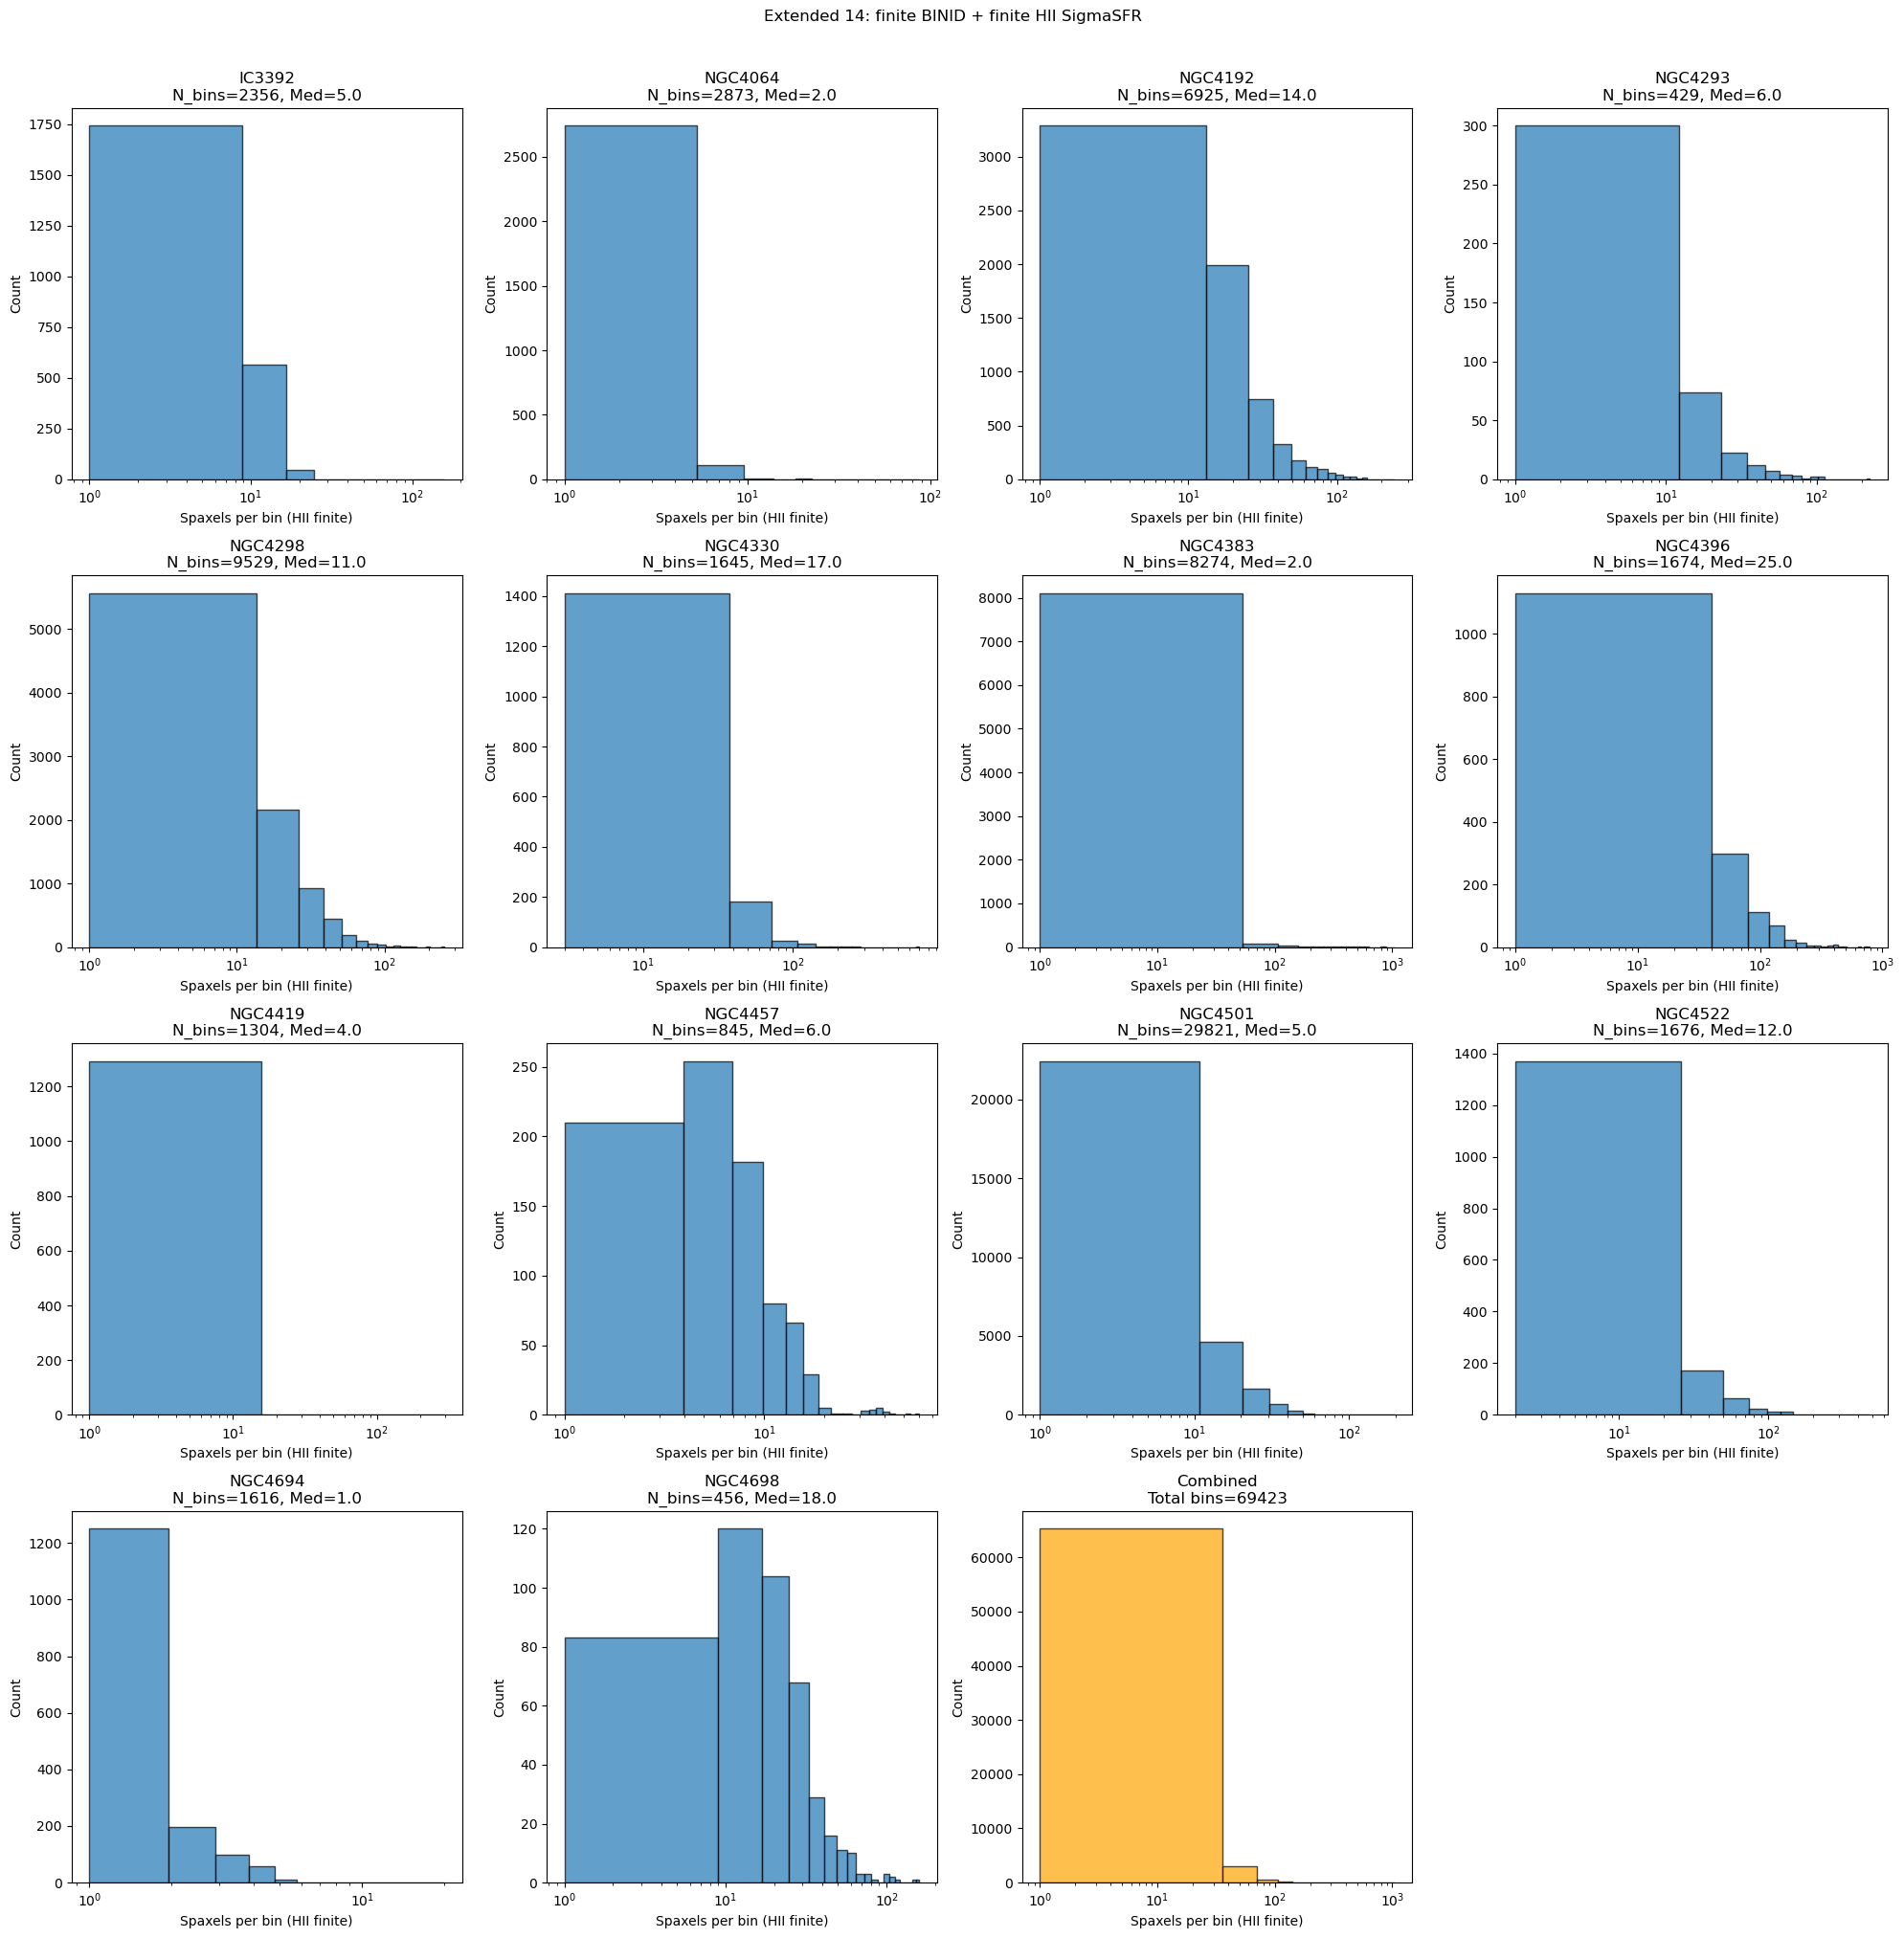

In [5]:
# Finite BINID plus finite HII SigmaSFR: original 14 extended galaxies
ext_stats_hii, ext_counts_hii, ext_all_hii, ext_warnings_hii = analyze_products(
    extended_products, 'extended_14', require_hii=True
)
print_with_combined(ext_stats_hii, ext_all_hii, 'Extended 14: finite BINID + finite HII SigmaSFR', 'extended_14', True)
if ext_warnings_hii:
    print('\nWarnings:')
    print('\n'.join(ext_warnings_hii))
plot_per_galaxy_histograms(ext_counts_hii, 'Extended 14: finite BINID + finite HII SigmaSFR', 'Spaxels per bin (HII finite)')

## 2. All available further galaxies


--- Further all: finite BINID only ---
   galaxy   mean median    std  min   max  num_bins                       top5  thr_68  thr_95  thr_997
   IC3392  23.28   9.00  80.36    1  1914      4062   1914,1311,1297,1262,1093      15      66      883
  NGC4064  19.82   5.00  48.94    1  1013      8954       1013,871,721,634,632      11      87      418
  NGC4189  36.13  21.00  87.70    1  2840      4893   2840,1894,1754,1638,1626      30     107      682
  NGC4192  15.21   8.00  29.24    1  1263     34395       1263,797,670,618,617      12      53      214
  NGC4293  12.76   7.00  19.10    1   594     20458        594,427,410,338,314      11      43      140
  NGC4294  39.37  13.00 135.55    1  4508      4531   4508,3512,2476,1909,1846      22     147      926
  NGC4298  40.96  12.00 167.37    1  5407     11808   5407,4942,3885,3297,3225      21     115     1421
  NGC4302  39.29  14.00 104.17    2  3456     10734   3456,3047,1922,1748,1587      23     151      795
  NGC4330  91.24  23.00 

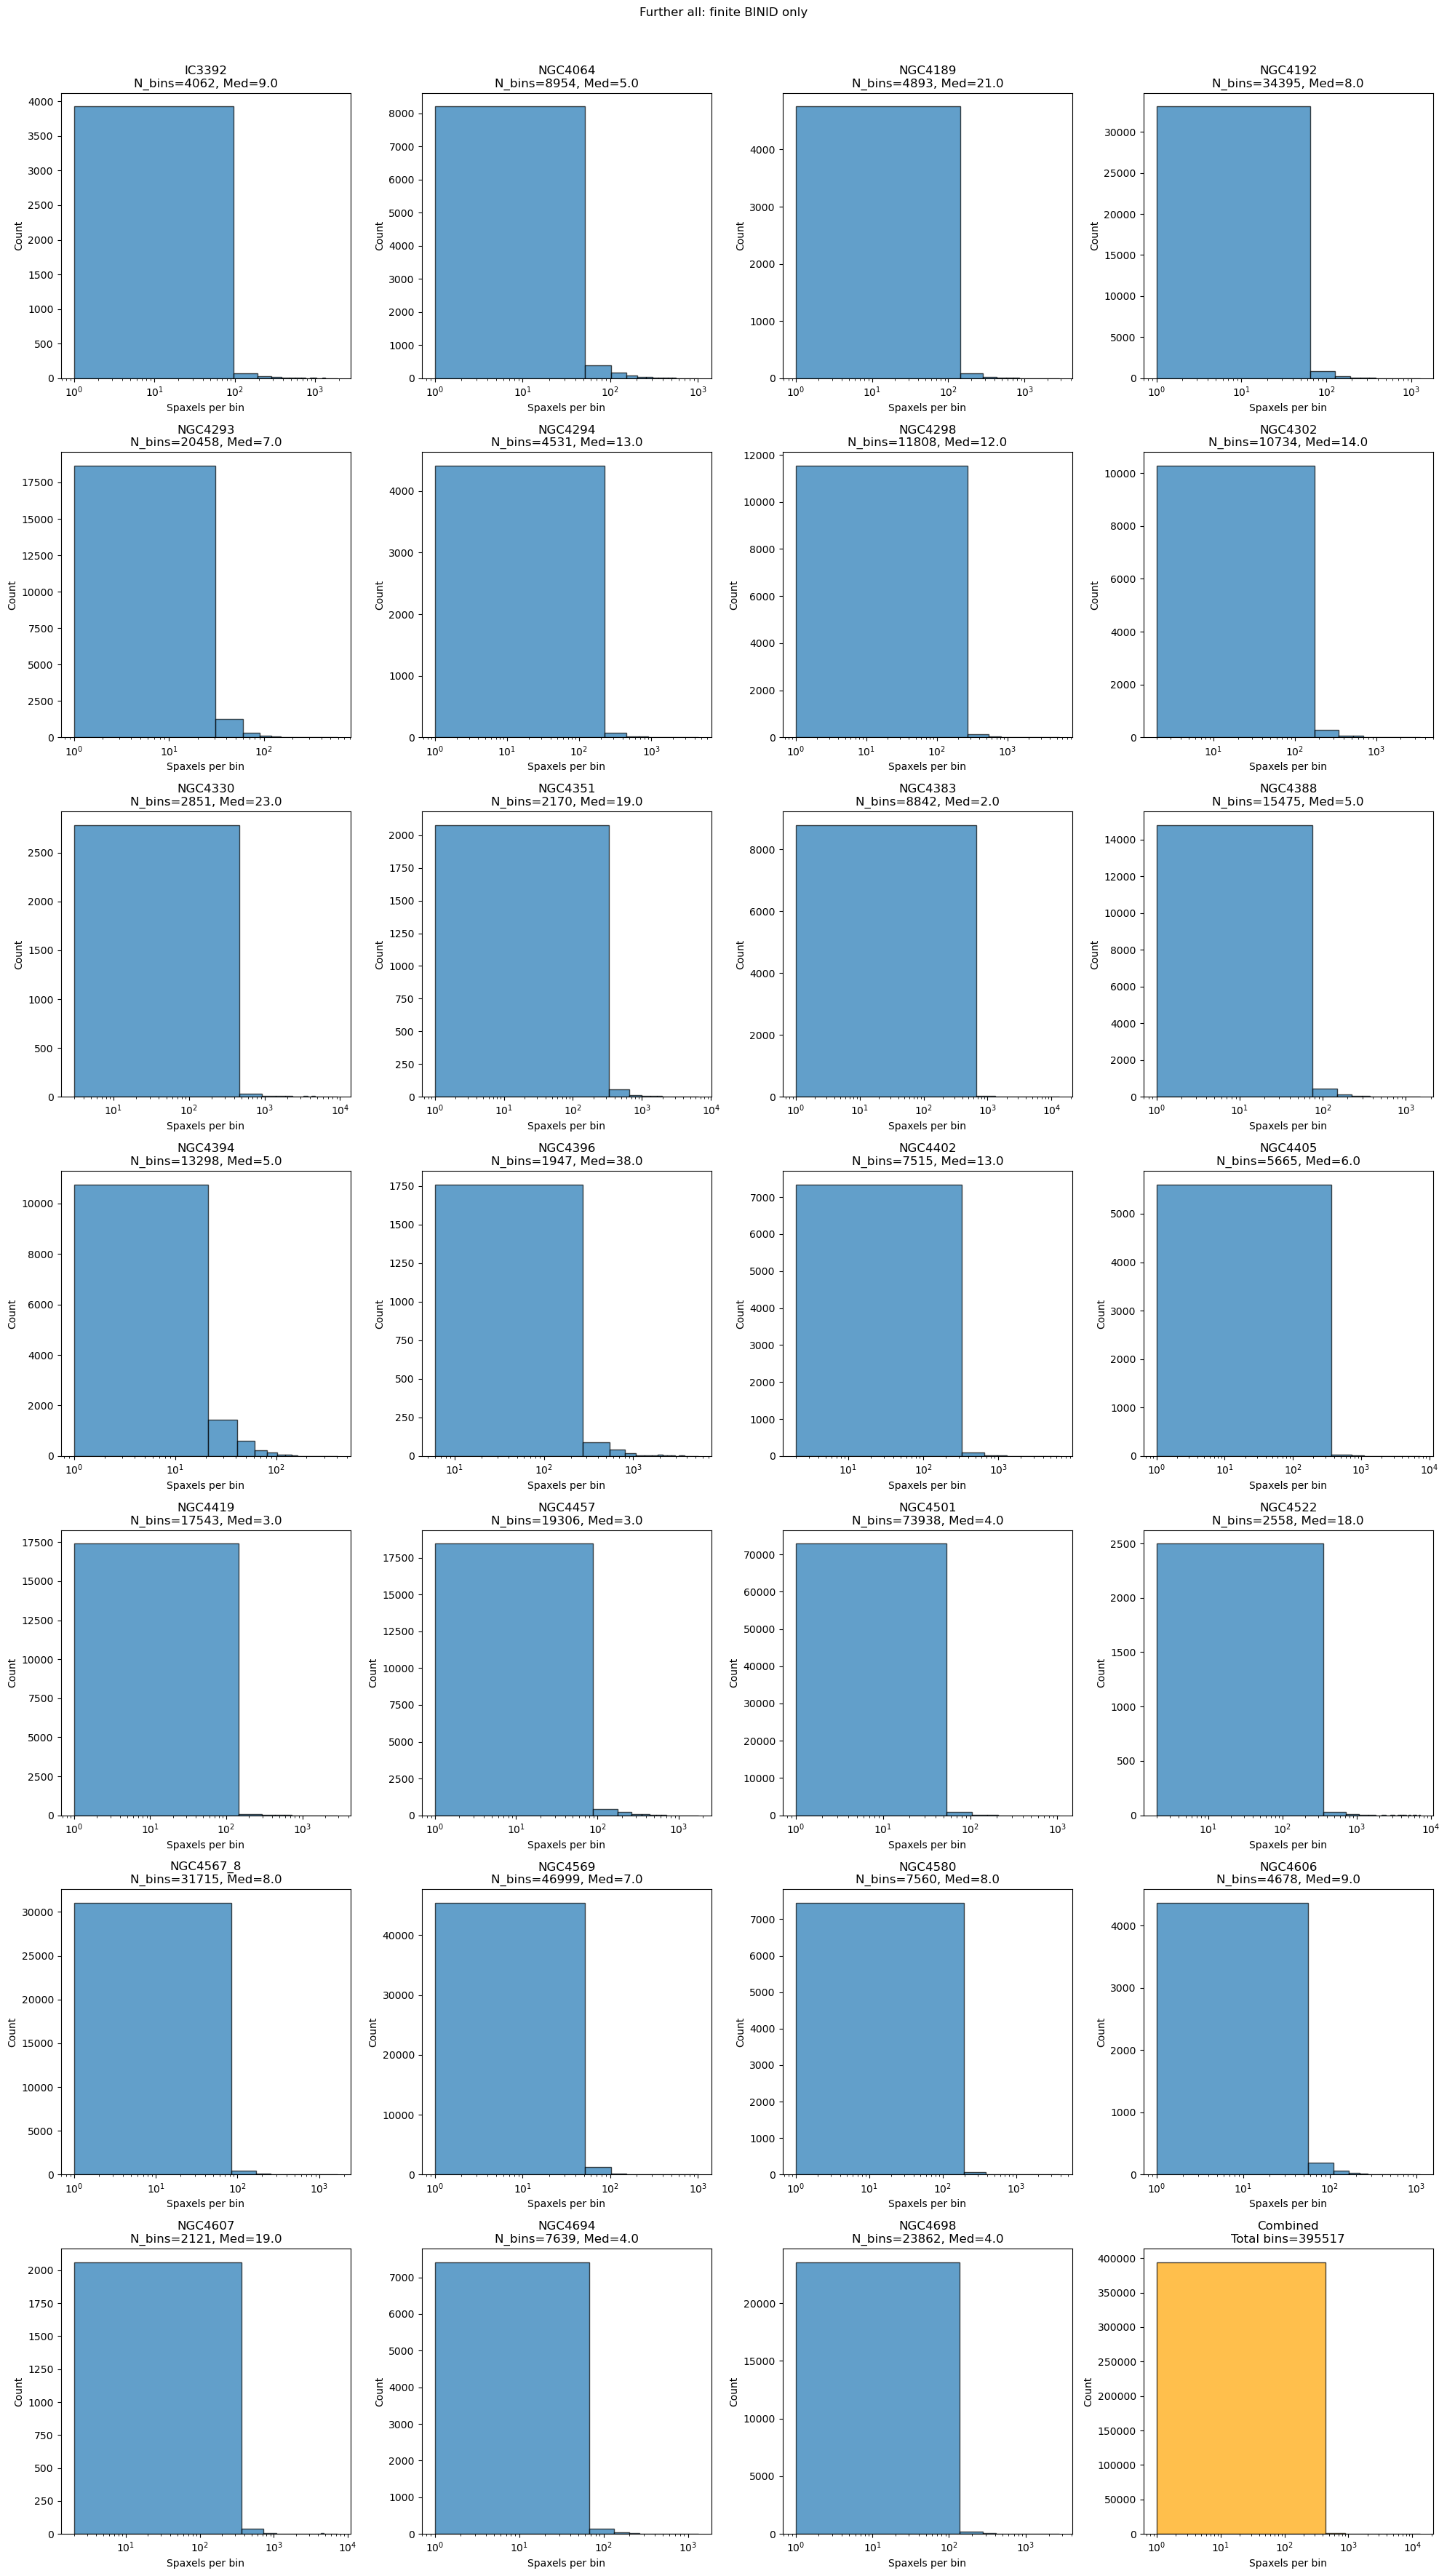

In [6]:
# Finite BINID only: all available further galaxies
fur_stats_binid, fur_counts_binid, fur_all_binid, fur_warnings_binid = analyze_products(
    further_products, 'further_all', require_hii=False
)
print_with_combined(fur_stats_binid, fur_all_binid, 'Further all: finite BINID only', 'further_all', False)
if fur_warnings_binid:
    print('\nWarnings:')
    print('\n'.join(fur_warnings_binid))
plot_per_galaxy_histograms(fur_counts_binid, 'Further all: finite BINID only', 'Spaxels per bin')


--- Further all: finite BINID + finite HII SigmaSFR ---
   galaxy  mean median    std  min   max  num_bins                      top5  thr_68  thr_95  thr_997
   IC3392  6.18   5.00   4.02    1    47      2404            47,22,21,21,20       8      14       19
  NGC4064  2.38   2.00   2.85    1    82      2930            82,54,46,34,34       2       5       23
  NGC4189 33.53  24.00  37.89    1   475      2978       475,452,446,435,360      34      95      296
  NGC4192 22.14  15.00  26.69    1   670      6999       670,453,372,350,317      22      66      174
  NGC4293 13.90   6.00  23.88    2   212       330       212,208,124,120,112       9      47      212
  NGC4294 21.00  11.00  30.30    1   420      3246       420,272,264,253,247      18      74      221
  NGC4298 17.46  11.00  20.48    1   369      9188       369,251,239,239,211      18      54      141
  NGC4302 20.94  14.00  27.05    2   555      2017       555,333,315,270,268      20      53      226
  NGC4330 23.94  17.00  2

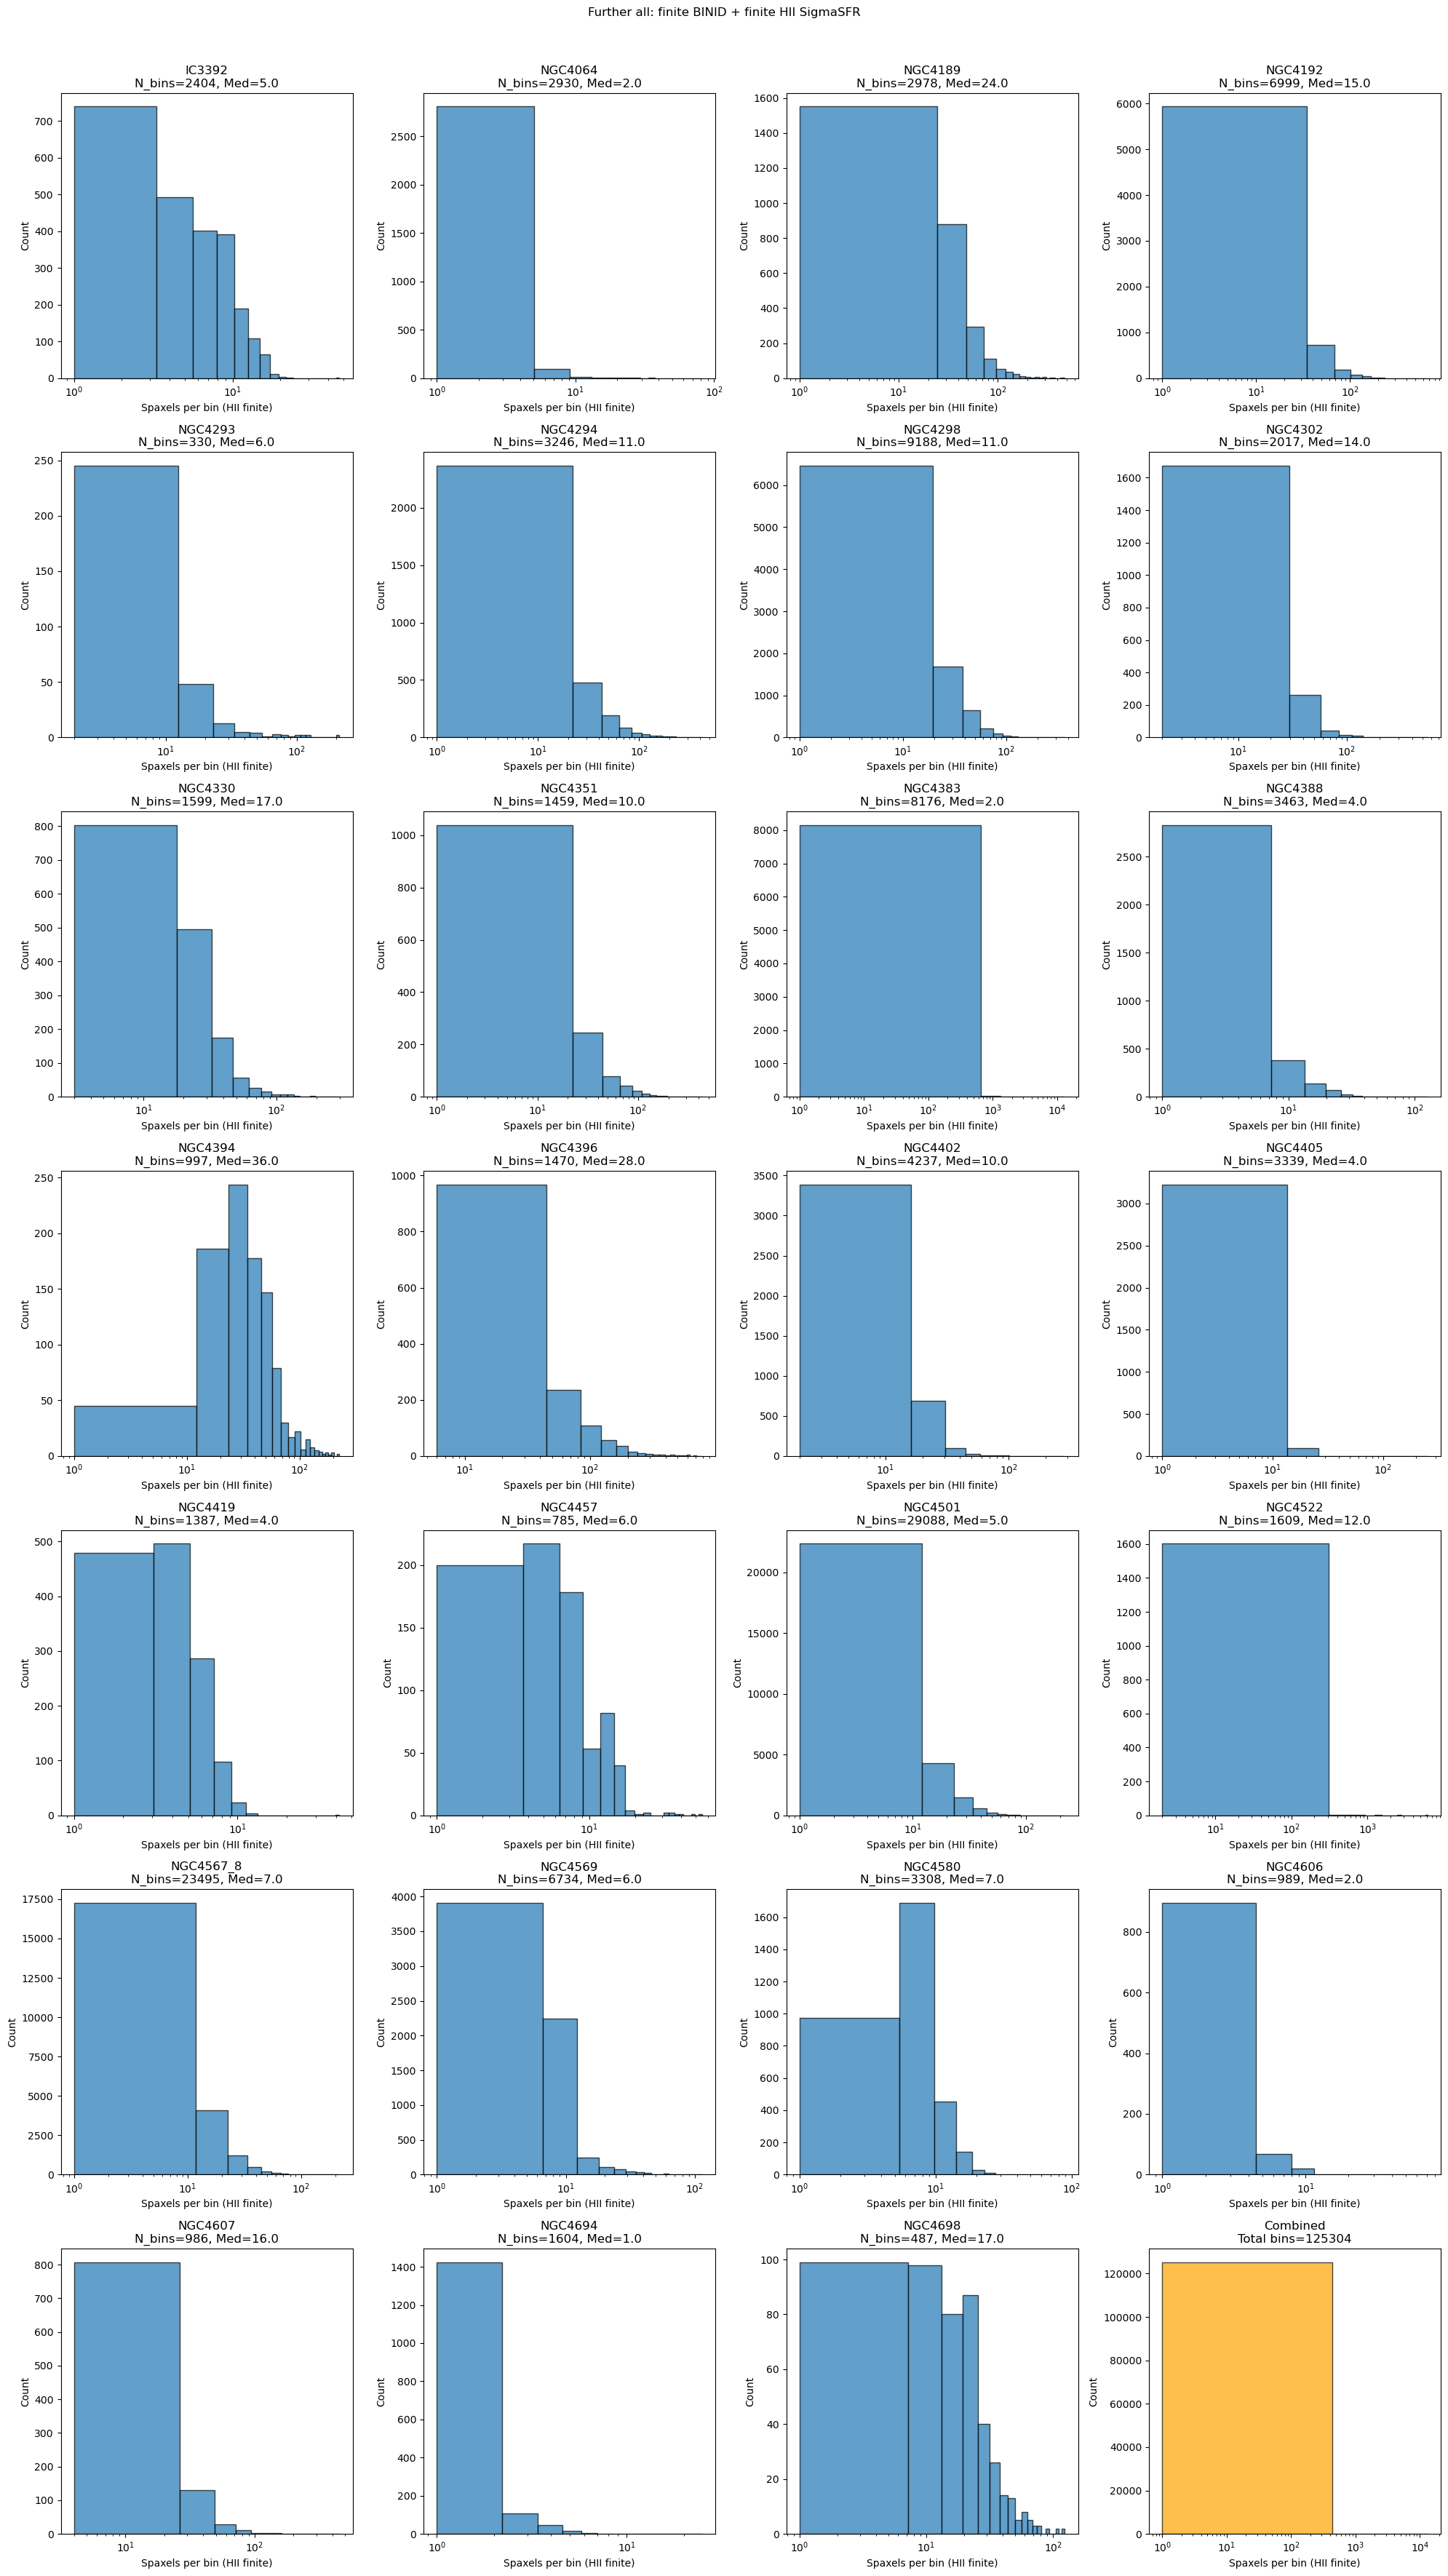

In [7]:
# Finite BINID plus finite HII SigmaSFR: all available further galaxies
fur_stats_hii, fur_counts_hii, fur_all_hii, fur_warnings_hii = analyze_products(
    further_products, 'further_all', require_hii=True
)
print_with_combined(fur_stats_hii, fur_all_hii, 'Further all: finite BINID + finite HII SigmaSFR', 'further_all', True)
if fur_warnings_hii:
    print('\nWarnings:')
    print('\n'.join(fur_warnings_hii))
plot_per_galaxy_histograms(fur_counts_hii, 'Further all: finite BINID + finite HII SigmaSFR', 'Spaxels per bin (HII finite)')

## 3. Matched extended/further comparison for co-existing galaxies

 galaxy  mean_extended  mean_further  delta_mean  ratio_mean  median_extended  median_further  delta_median  ratio_median  max_extended  max_further  delta_max  ratio_max  num_bins_extended  num_bins_further  delta_num_bins  ratio_num_bins  thr_68_extended  thr_68_further  delta_thr_68  ratio_thr_68  thr_95_extended  thr_95_further  delta_thr_95  ratio_thr_95  thr_997_extended  thr_997_further  delta_thr_997  ratio_thr_997
 IC3392      17.946529     23.282866    5.336336    1.297346              9.0             9.0           0.0      1.000000           431         1914       1483   4.440835               4077              4062             -15        0.996321               14              15             1      1.071429               58              66             8      1.137931               296              883            587       2.983108
NGC4064      16.736479     19.823543    3.087064    1.184451              5.0             5.0           0.0      1.000000           383         10

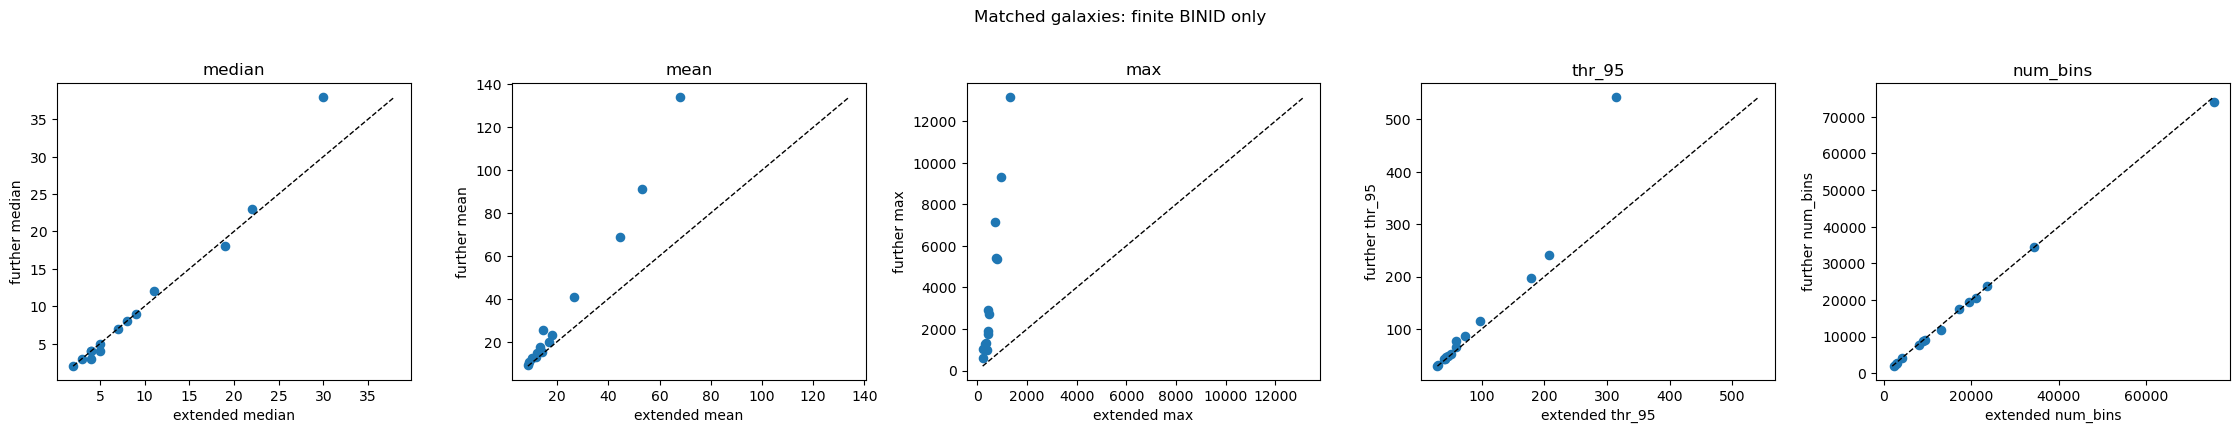

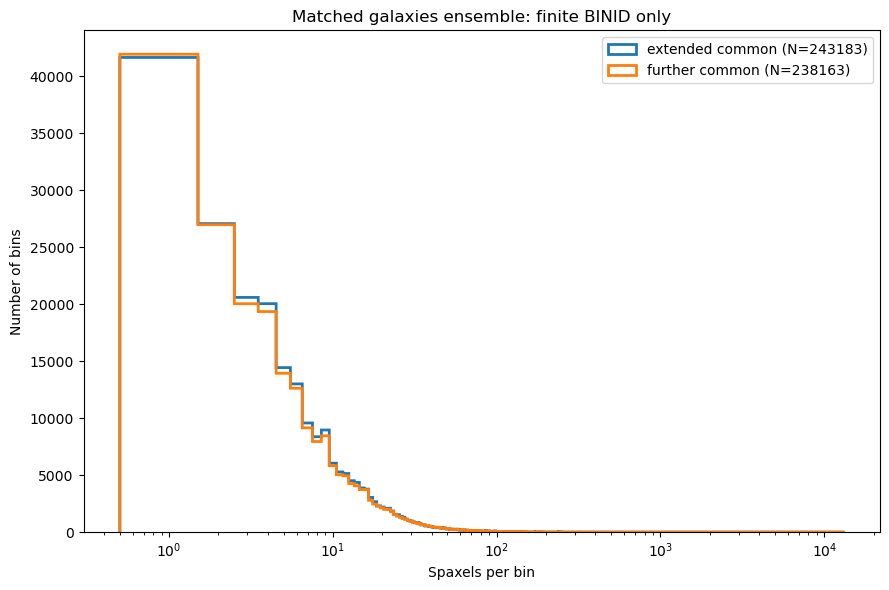

In [8]:
# Matched 14-galaxy comparison: finite BINID only
ext_common_stats_binid, ext_common_counts_binid, ext_common_all_binid, _ = analyze_products(
    extended_common_products, 'extended_common', require_hii=False
)
fur_common_stats_binid, fur_common_counts_binid, fur_common_all_binid, _ = analyze_products(
    further_common_products, 'further_common', require_hii=False
)
common_comp_binid = compare_stats(ext_common_stats_binid, fur_common_stats_binid, 'extended', 'further')
print(common_comp_binid.to_string(index=False))
plot_paired_metric_comparison(common_comp_binid, 'extended', 'further', 'Matched galaxies: finite BINID only')
plot_ensemble_overlay(
    {'extended common': ext_common_all_binid, 'further common': fur_common_all_binid},
    'Matched galaxies ensemble: finite BINID only',
    'Spaxels per bin',
)

 galaxy  mean_extended  mean_further  delta_mean  ratio_mean  median_extended  median_further  delta_median  ratio_median  max_extended  max_further  delta_max  ratio_max  num_bins_extended  num_bins_further  delta_num_bins  ratio_num_bins  thr_68_extended  thr_68_further  delta_thr_68  ratio_thr_68  thr_95_extended  thr_95_further  delta_thr_95  ratio_thr_95  thr_997_extended  thr_997_further  delta_thr_997  ratio_thr_997
 IC3392       6.326825      6.175125   -0.151700    0.976023              5.0             5.0           0.0      1.000000           158           47       -111   0.297468               2356              2404              48        1.020374                7               8             1      1.142857               14              14             0      1.000000                21               19             -2       0.904762
NGC4064       2.463279      2.375085   -0.088193    0.964197              2.0             2.0           0.0      1.000000            87           

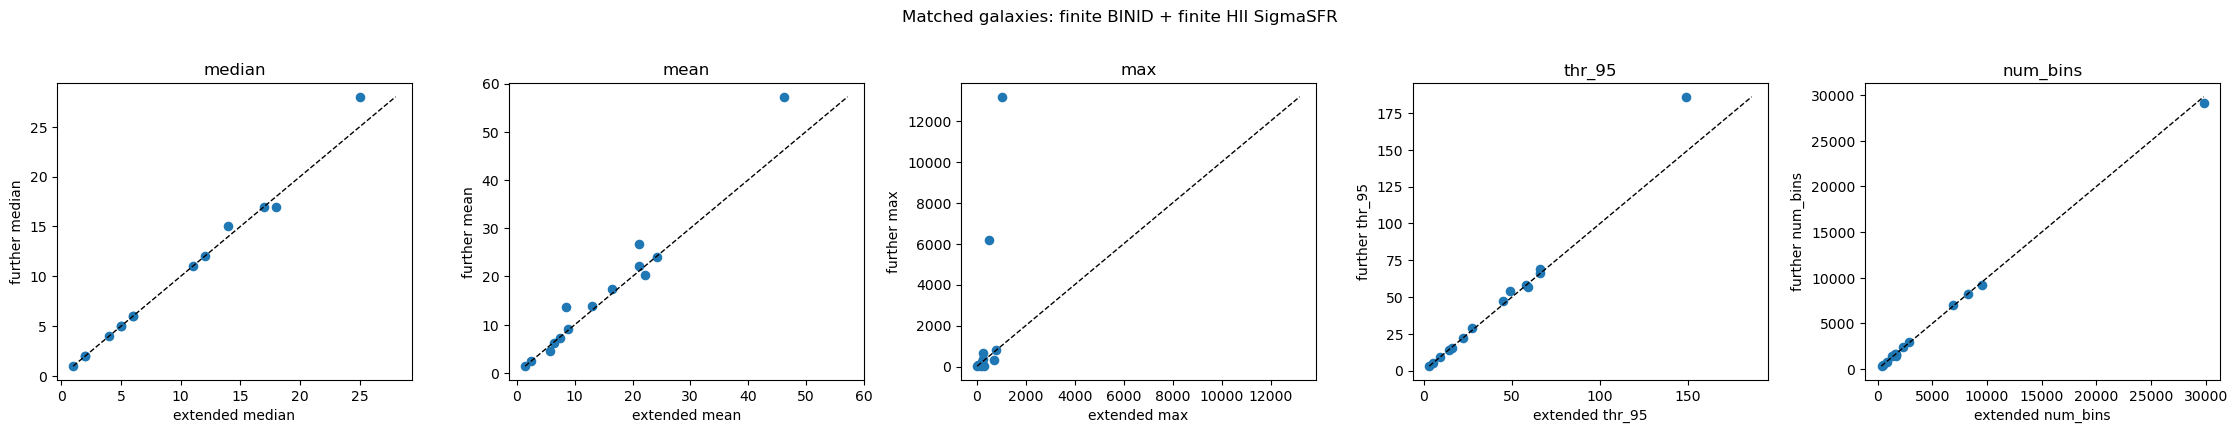

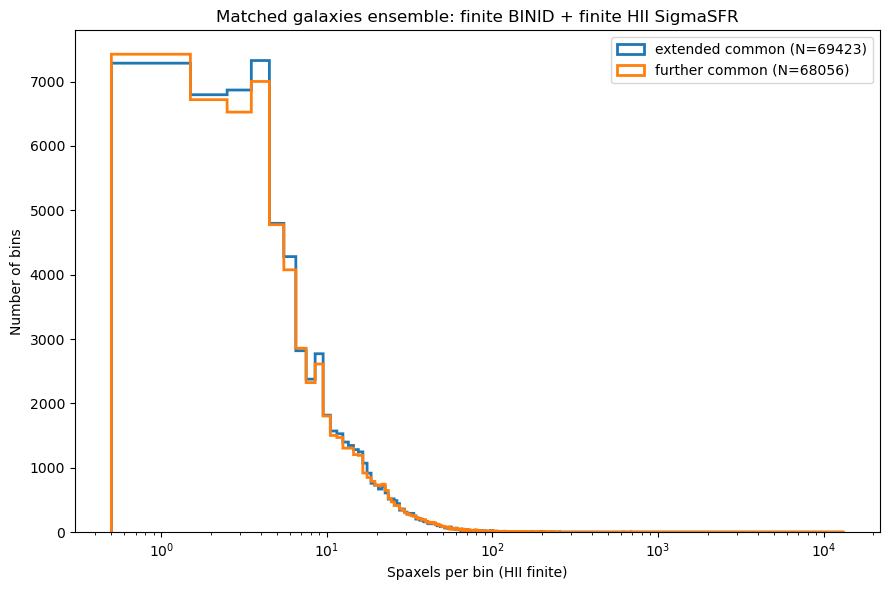

In [9]:
# Matched 14-galaxy comparison: finite BINID plus finite HII SigmaSFR
ext_common_stats_hii, ext_common_counts_hii, ext_common_all_hii, ext_common_warnings_hii = analyze_products(
    extended_common_products, 'extended_common', require_hii=True
)
fur_common_stats_hii, fur_common_counts_hii, fur_common_all_hii, fur_common_warnings_hii = analyze_products(
    further_common_products, 'further_common', require_hii=True
)
common_comp_hii = compare_stats(ext_common_stats_hii, fur_common_stats_hii, 'extended', 'further')
print(common_comp_hii.to_string(index=False))
for warnings in (ext_common_warnings_hii, fur_common_warnings_hii):
    if warnings:
        print('\nWarnings:')
        print('\n'.join(warnings))
plot_paired_metric_comparison(common_comp_hii, 'extended', 'further', 'Matched galaxies: finite BINID + finite HII SigmaSFR')
plot_ensemble_overlay(
    {'extended common': ext_common_all_hii, 'further common': fur_common_all_hii},
    'Matched galaxies ensemble: finite BINID + finite HII SigmaSFR',
    'Spaxels per bin (HII finite)',
)

## 4. Ensemble comparison: extended 14 vs all available further galaxies

     sample   galaxy         mask      mean  median       std  min   max  num_bins                       top5  thr_68  thr_95  thr_997
extended_14 Combined finite_BINID 13.623539     5.0 33.432498    1  1313    243183    1313,1117,1046,1022,974      10      47      279
further_all Combined finite_BINID 19.293484     6.0 99.912855    1 13168    395517 13168,10586,9295,7306,7305      12      58      491


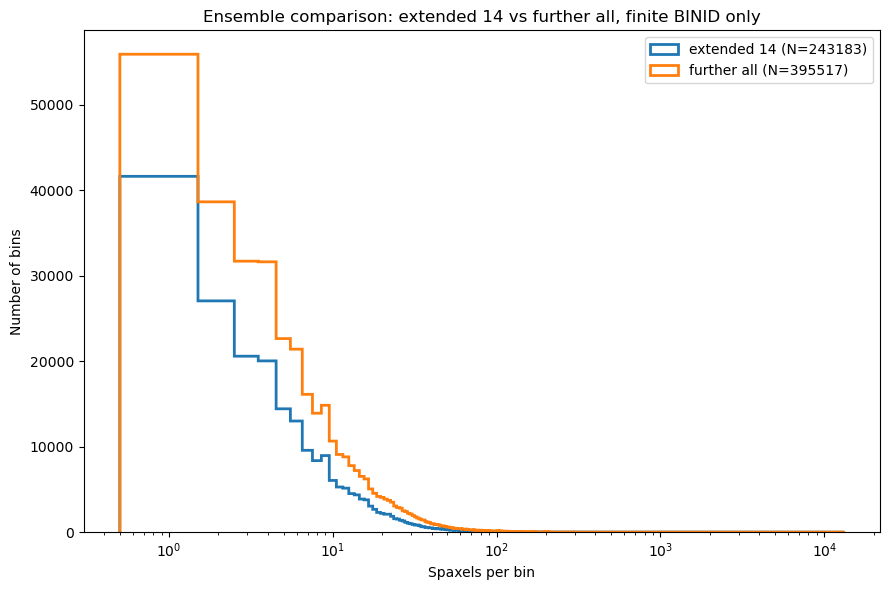

In [10]:
# Ensemble comparison, all available products: finite BINID only
ensemble_binid = pd.DataFrame([
    combined_stats_row('extended_14', ext_all_binid, 'finite_BINID'),
    combined_stats_row('further_all', fur_all_binid, 'finite_BINID'),
]).dropna(how='all')
print(ensemble_binid.to_string(index=False))
plot_ensemble_overlay(
    {'extended 14': ext_all_binid, 'further all': fur_all_binid},
    'Ensemble comparison: extended 14 vs further all, finite BINID only',
    'Spaxels per bin',
)

     sample   galaxy                          mask      mean  median       std  min   max  num_bins                      top5  thr_68  thr_95  thr_997
extended_14 Combined finite_BINID_and_HII_SigmaSFR 12.117627     6.0 24.543135    1  1046     69423      1046,955,914,898,862      11      39      155
further_all Combined finite_BINID_and_HII_SigmaSFR 12.860986     6.0 56.436039    1 13168    125304 13168,6296,6160,5785,3433      11      40      161


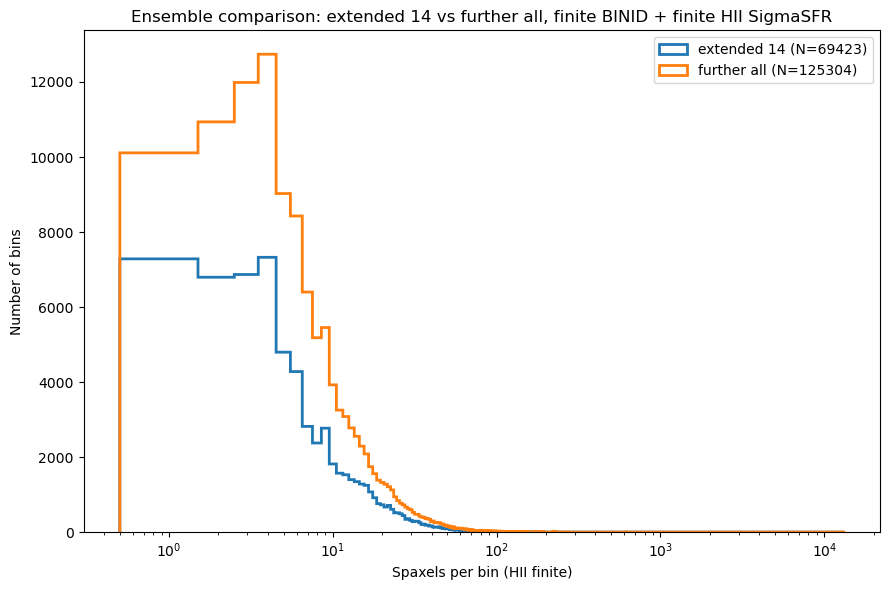

In [11]:
# Ensemble comparison, all available products: finite BINID plus finite HII SigmaSFR
ensemble_hii = pd.DataFrame([
    combined_stats_row('extended_14', ext_all_hii, 'finite_BINID_and_HII_SigmaSFR'),
    combined_stats_row('further_all', fur_all_hii, 'finite_BINID_and_HII_SigmaSFR'),
]).dropna(how='all')
print(ensemble_hii.to_string(index=False))
plot_ensemble_overlay(
    {'extended 14': ext_all_hii, 'further all': fur_all_hii},
    'Ensemble comparison: extended 14 vs further all, finite BINID + finite HII SigmaSFR',
    'Spaxels per bin (HII finite)',
)